In [1]:
# IMPORTS
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# Module imports
from prp.task_generator import generate_task_patterns, generate_fixed_task_set
from prp.nn_wrapper import TaskNetworkWrapper
from prp.prp_simulator import sweep_soa, run_prp_trial
from prp.training_utils import train_with_optional_multitask, train_with_control_config 
from prp.threshold_utils import optimize_lca_threshold, choose_onset_policy, optimize_reward_rate_threshold


# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)


In [2]:
# Reload module when making live edits
import importlib
import prp.prp_simulator as prp_simulator
importlib.reload(prp_simulator)

<module 'prp.prp_simulator' from '/home/acesmeci/Code/prp_model/prp/prp_simulator.py'>

In [ ]:
# Train the model. Ideally use python scripts/train_model.py in terminal instead.

# Generate fixed task set A–E for training
inp, task, target, _ = generate_fixed_task_set(
    N_pathways=3,
    N_features=3,
    samples_per_task=100,
)

net = TaskNetworkWrapper(hidden_size=100)
net.train_online(inp, task, target, stop_loss=0.001) # Paper stop_loss = 0.001

# Save model after training
torch.save(net.model.state_dict(), "../output/trained_model_0001.pth")
print("✅ Model saved to output/trained_model.pth")


In [2]:
# New model loading cell
from prp.nn_wrapper import TaskNetworkWrapper
import torch

# Match exactly what you used in scripts/train_model.py:
wrapper = TaskNetworkWrapper(
    stim_input_dim = 3 * 3,    # N_pathways * N_features
    task_input_dim = 3 ** 2,   # N_pathways^2
    hidden_dim     = 100,
    output_dim     = 3 * 3,
    learning_rate  = 0.3,
    device         = "cpu"
)

# Now load
wrapper.model.load_state_dict(torch.load("../output/trained_models/trained_model.pth"))
wrapper.model.eval()
print("✅ Loaded model, ready for inference.")

✅ Loaded model, ready for inference.


In [3]:
# === Notebook cell: compute fixed Task-B threshold ===

import numpy as np
import torch
from prp.task_generator   import generate_fixed_task_set
from prp.threshold_utils  import optimize_lca_threshold_dist
from prp.lca              import run_lca_avg

# 1) Get a batch of Task B examples
inp, tasks_sgl, train_sgl, meta = generate_fixed_task_set(seed=SEED)
mask_B = (meta["task_indices"] == "B")
input_B  = inp[mask_B]
task_B   = tasks_sgl[mask_B]

# 2) Pick one representative trial (or average across several)
input_b = input_B[0]
task_b  = task_B[0]

# 3) Run the network with no carry-over (pure single-task B)
output_series_th = wrapper.integrate(
    torch.from_numpy(input_b[None,:]).float(),
    torch.from_numpy(task_b[None,:]).float(),
    persistence=0.0
)
output_np = np.stack([o.numpy() for o in output_series_th], axis=0)

# 4) Decode which output indices correspond to B
N_pathways, N_features = 3, 3
mat_B = task_b.reshape(N_pathways, N_pathways).T
in_B, out_B = np.argwhere(mat_B==1)[0]
idxs_b = list(range(out_B*N_features, (out_B+1)*N_features))
correct_b = np.argmax(input_b[in_B*N_features:(in_B+1)*N_features])

# 5) Fit LCA threshold once
thresholds = np.arange(0.0, 1.6, 0.1)
z_B, rr_B = optimize_lca_threshold_dist(
    output_np, idxs_b, correct_response_idx=correct_b,
    thresholds=thresholds, ITI=0.5, n_repeats=100
)
print("Fixed Task B threshold =", z_B)

Fixed Task B threshold = 0.2


/home/acesmeci/Code/prp_model/prp/lca.py:171: RuntimeWarning: Mean of empty slice
  rts = np.nanmean(all_rts, axis=1)


In [9]:
# PRP Simulator. Takes ~2 minutes to run with 10 trials per SOA.
# ~5 minutes with 50 trials per SOA.

# Efficient pairwise trial generator
def generate_trial_pair(prp_pair=("B", "A"), N_pathways=3, N_features=3, seed=SEED):
    """
    Generate a single PRP trial from a specific task pair (e.g., B → A).
    Only creates the required two tasks, unlike generate_fixed_task_set().
    """

    task_map = {
        'A': (0, 0),
        'B': (1, 1),
        'C': (2, 2),
        'D': (0, 1),
        'E': (1, 0)
    }

    def sample_single_task(task_name):
        in_dim, out_dim = task_map[task_name]
        stim = np.zeros(N_pathways * N_features)
        features = np.random.randint(0, N_features, size=N_pathways)
        for i in range(N_pathways):
            stim[i * N_features + features[i]] = 1

        task_vec = np.zeros(N_pathways**2)
        task_vec[in_dim * N_pathways + out_dim] = 1

        target = np.zeros(N_pathways * N_features)
        target[out_dim * N_features + features[in_dim]] = 1

        return stim, task_vec, target

    stim1, task1, _ = sample_single_task(prp_pair[0])
    stim2, task2, _ = sample_single_task(prp_pair[1])
    return stim1, stim2, task1, task2 # Changed the order of stim1-2 and task1-2 to check if order is important


# ✅ Optional test calls
_ = generate_trial_pair(prp_pair=("B", "A"))
_ = generate_trial_pair(prp_pair=("C", "A"))


# ✅ Sweep for B → A (functionally dependent)
results_ba = sweep_soa(
    task_net=wrapper,
    trial_generator=lambda: generate_trial_pair(("B", "A")),
    soa_values=list(range(0, 9)),  # SOAs 0–8
    n_trials_per_soa=50,           # Optional: increase to 50 for final experiments
    persistence=0.8, # run with 0.9
    z_b_fixed=1.0,  # Use the fixed threshold from Task B
    verbose=False
)

# ✅ Sweep for C → A (functionally independent)
results_ca = sweep_soa(
    task_net=wrapper,
    trial_generator=lambda: generate_trial_pair(("C", "A")),
    soa_values=list(range(0, 9)), # changed dt = 0.05, so this should cover 50ms to 400ms
    n_trials_per_soa=50,
    persistence=0.8, # 0.9 for proper interference.
    z_b_fixed=1.0,
    verbose=False
)

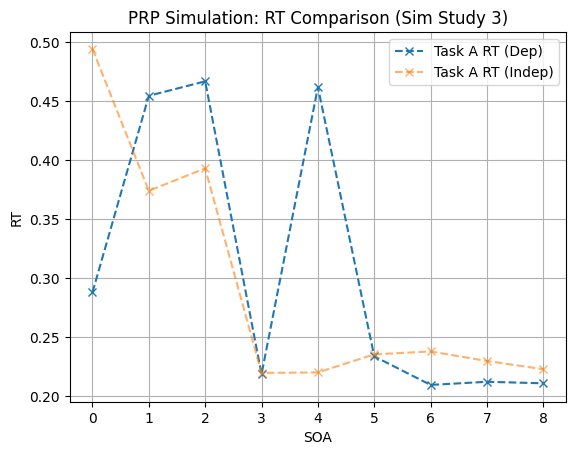

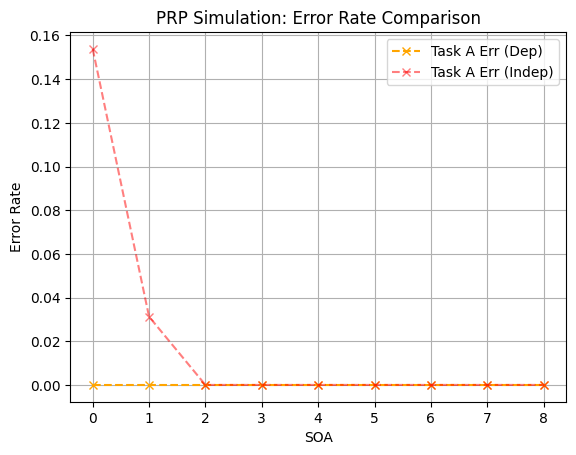

In [10]:
# Plot RTs and Error Rates

# RTs
#plt.plot(results_ba["soa"], results_ba["rt_b"], label="Task B RT (Dep)", marker='o')
plt.plot(results_ba["soa"], results_ba["rt_a"], label="Task A RT (Dep)", marker='x', linestyle='--')

#plt.plot(results_ca["soa"], results_ca["rt_b"], label="Task C RT (Indep)", marker='o', alpha=0.6)
plt.plot(results_ca["soa"], results_ca["rt_a"], label="Task A RT (Indep)", marker='x', linestyle='--', alpha=0.6)

plt.xlabel("SOA")
plt.ylabel("RT")
plt.title("PRP Simulation: RT Comparison (Sim Study 3)")
plt.grid(True)
plt.legend()
#plt.savefig("../output/plots/RT_p099_zb10_nt50_ITI05.png", dpi=300)
plt.show()

# Error Rates
err_a_ba = [1 - a if not np.isnan(a) else np.nan for a in results_ba["acc_a"]]
err_b_ba = [1 - b if not np.isnan(b) else np.nan for b in results_ba["acc_b"]]
err_a_ca = [1 - a if not np.isnan(a) else np.nan for a in results_ca["acc_a"]]
err_c_ca = [1 - b if not np.isnan(b) else np.nan for b in results_ca["acc_b"]]

#plt.plot(results_ba["soa"], err_b_ba, marker='o', label="Task B Err (Dep)", color="cyan")
plt.plot(results_ba["soa"], err_a_ba, marker='x', linestyle='--', label="Task A Err (Dep)", color="orange")

#plt.plot(results_ca["soa"], err_c_ca, marker='o', label="Task C Err (Indep)", color="darkblue", alpha=0.5)
plt.plot(results_ca["soa"], err_a_ca, marker='x', linestyle='--', label="Task A Err (Indep)", color="red", alpha=0.5)

plt.xlabel("SOA")
plt.ylabel("Error Rate")
plt.title("PRP Simulation: Error Rate Comparison")
plt.grid(True)
plt.legend()
#plt.savefig("../output/plots/ER_p099_zb10_nt50_ITI05.png", dpi=300)
plt.show()

# Diagnostics

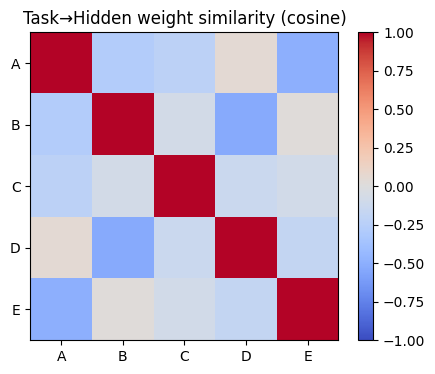

sim(A,D)= 0.047545742243528366
sim(B,E)= 0.019557887688279152
sim(A,B)= -0.2810686528682709


In [12]:
import numpy as np, torch
import matplotlib.pyplot as plt

# Map task one-hot to column index in fc_task_hidden (9 cols for 3x3)
def task_onehot_to_col(task_vec, N_pathways=3):
    mat = task_vec.reshape(N_pathways, N_pathways).T
    i_in, i_out = np.argwhere(mat == 1)[0]
    return int(i_out * N_pathways + i_in)

# Pull one canonical one-hot for A..E
from prp.task_generator import generate_fixed_task_set
inp, task_onehots, _, meta = generate_fixed_task_set(seed=42)
labels = ['A','B','C','D','E']
cols = {lab: task_onehot_to_col(task_onehots[np.where(meta["task_indices"]==lab)[0][0]]) for lab in labels}

# Get the task→hidden matrix (H x 9)
W_th = wrapper.model.fc_task_hidden.weight.detach().cpu().numpy()  # shape: (H, 9)

def cosine(a,b):
    an, bn = np.linalg.norm(a)+1e-8, np.linalg.norm(b)+1e-8
    return float(np.dot(a,b)/(an*bn))

S = np.zeros((5,5))
for i, li in enumerate(labels):
    for j, lj in enumerate(labels):
        S[i,j] = cosine(W_th[:, cols[li]], W_th[:, cols[lj]])

plt.figure(figsize=(5,4))
plt.imshow(S, vmin=-1, vmax=1, cmap='coolwarm')
plt.colorbar()
plt.xticks(range(5), labels); plt.yticks(range(5), labels)
plt.title("Task→Hidden weight similarity (cosine)")
plt.show()

print("sim(A,D)=", S[labels.index('A'), labels.index('D')])
print("sim(B,E)=", S[labels.index('B'), labels.index('E')])
print("sim(A,B)=", S[labels.index('A'), labels.index('B')])
